In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
from pyprojroot import here

In [2]:
RAW_DATA_DIR = here() / "data" / "raw"
INTERIM_DATA_DIR = here() / "data" / "interim"
PROCESSED_DATA_DIR = here() / "data" / "processed"
RESULTS_DATA_DIR = here() / "results"

In [3]:
gdf = gpd.read_file(RAW_DATA_DIR/'geography/municipalities/00mun.shp')
df_fuzzy = pd.read_csv(PROCESSED_DATA_DIR/"RELMS_index.csv", encoding="utf-8")

In [4]:
gdf['CVEGEO'] = gdf['CVEGEO'].astype(str).str.zfill(5)
df_fuzzy['CVEGEO'] = df_fuzzy['CVEGEO'].astype(str).str.zfill(5)

gdf = gdf.merge(df_fuzzy[['CVEGEO', 'RELM_index']], on='CVEGEO', how='left')


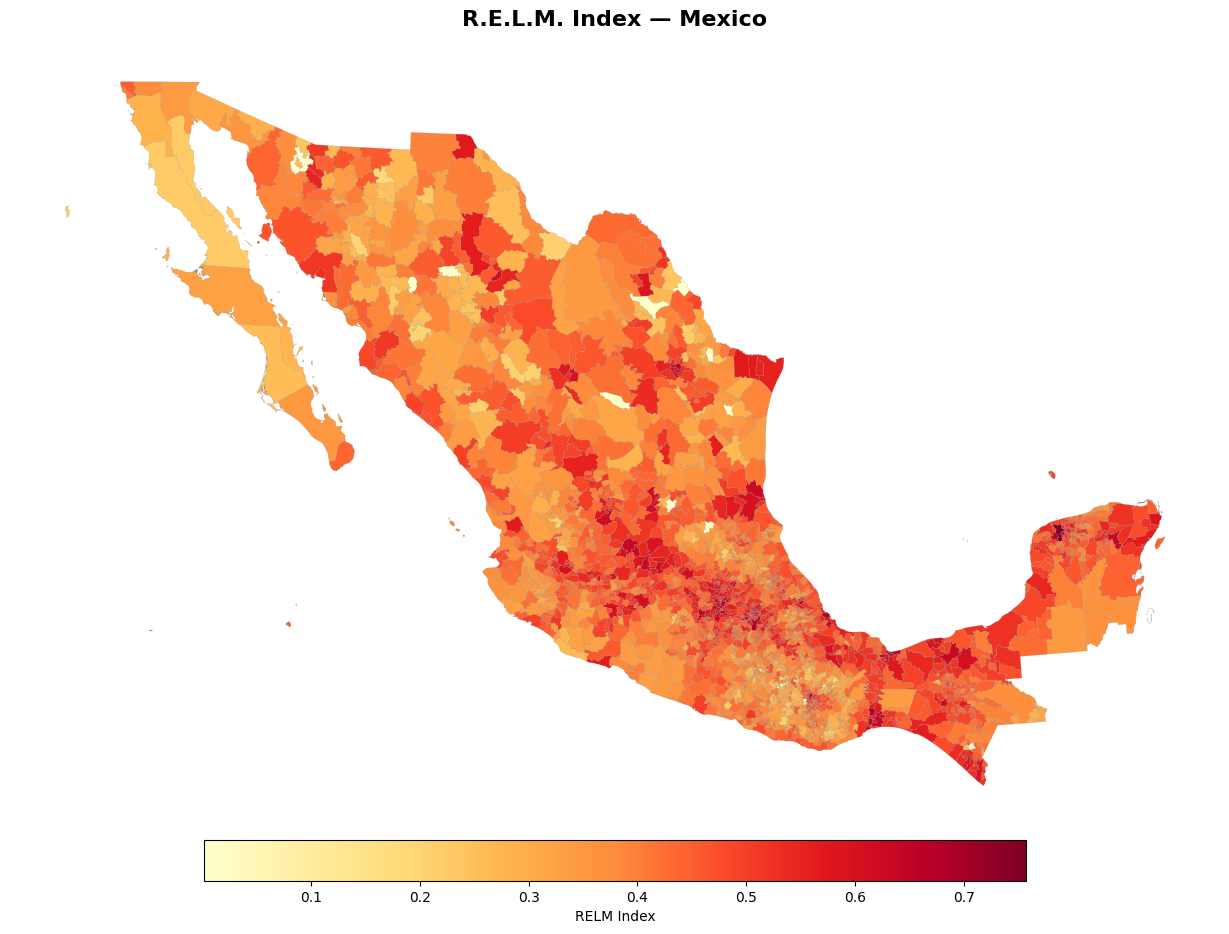

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

gdf.plot(
    column='RELM_index',
    cmap='YlOrRd',
    linewidth=0.1,
    edgecolor='grey',
    legend=True,
    legend_kwds={
        'label': 'RELM Index',
        'orientation': 'horizontal',
        'shrink': 0.6,
        'pad': 0.02
    },
    missing_kwds={'color': 'lightgrey', 'label': 'No data'},
    ax=ax
)

ax.set_title('R.E.L.M. Index — Mexico', fontsize=16, fontweight='bold', pad=15)
ax.axis('off')

plt.tight_layout()
plt.savefig(RESULTS_DATA_DIR/'maps/RELM_heatmap1.png', dpi=300, bbox_inches='tight')
plt.show()